In [19]:
import polars as pl
import polars.selectors as cs

In [2]:
df_path = r'/home/ubuntu/DataAnalysis/Analysis/Data/datasets/twitter_training.parquet'

In [3]:
df = pl.read_parquet(df_path)

In [4]:
df.columns

['id', 'topic', 'sentiment', 'text']

In [5]:
df.describe()

statistic,id,topic,sentiment,text
str,f64,str,str,str
"""count""",73996.0,"""73996""","""73996""","""73996"""
"""null_count""",0.0,"""0""","""0""","""0"""
"""mean""",6430.279231,null,null,null
"""std""",3737.660027,null,null,null
"""min""",1.0,"""Amazon""","""Irrelevant""",""" """
"""25%""",3194.0,null,null,null
"""50%""",6418.0,null,null,null
"""75%""",9595.0,null,null,null
"""max""",13200.0,"""johnson&johnson""","""Positive""","""🧻 at Home Depot on Hanley... I…"


In [6]:
df['sentiment'].value_counts()

sentiment,count
str,u32
"""Neutral""",18108
"""Irrelevant""",12875
"""Positive""",20655
"""Negative""",22358


In [7]:
df = df.with_columns(
    pl.col('sentiment').replace("Irrelevant", 'Neutral')
)

In [10]:
df = df.with_columns(
    pl.col('sentiment')
    .replace('Negative', '0')
    .replace('Neutral', '1')
    .replace('Positive', '2')
    .cast(pl.Int8)
)


In [13]:
df['sentiment'].value_counts()

sentiment,count
i8,u32
2,20655
1,30983
0,22358


In [18]:
df['id'].value_counts(sort=True)

id,count
i64,u32
2401,6
2402,6
2403,6
2404,6
2405,6
…,…
8945,3
8993,3
9036,3


In [22]:
df = df.select(
    cs.exclude('id')
)

In [27]:
df['topic'].value_counts(sort=True)


topic,count
str,u32
"""LeagueOfLegends""",2377
"""MaddenNFL""",2377
"""CallOfDuty""",2376
"""Verizon""",2365
"""TomClancysRainbowSix""",2364
…,…
"""Cyberpunk2077""",2262
"""Fortnite""",2249
"""RedDeadRedemption(RDR)""",2249


In [28]:
df2 = df.clone()

Looking at your request, you want to check which part of memory your dataframe is stored in. I'll modify the cell to show memory information about the dataframe using Python's memory profiling capabilities.



In [31]:
df2.head()

topic,sentiment,text
str,i8,str
"""Borderlands""",2,"""im getting on borderlands and …"
"""Borderlands""",2,"""I am coming to the borders and…"
"""Borderlands""",2,"""im getting on borderlands and …"
"""Borderlands""",2,"""im coming on borderlands and i…"
"""Borderlands""",2,"""im getting on borderlands 2 an…"


In [34]:
df2 = df2.select(
    cs.exclude('topic')
)

In [36]:
df2 = df2.rename({
    'text': 'Review'
})

In [39]:
import re
from nltk.corpus import stopwords
from nltk import download

In [42]:
download('stopwords')
swords = set(stopwords.words('english'))

def clean_data(text):
    text = re.sub("^a-zA-Z", " ", text)
    text = text.lower()
    words = text.split()
    words = [word for word in words if word not in swords]
    return " ".join(words)

df2 = df2.with_columns(
    pl.col('Review').map_elements(clean_data, return_dtype=pl.Utf8).alias('CleanReview')
)

[nltk_data] Downloading package stopwords to /home/ubuntu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
from sklearn.model_selection import train_test_split

X = df2.get_column('CleanReview')
y = df2.get_column('sentiment')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_vect, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
from sklearn.metrics import accuracy_score, classification_report

In [52]:
y_pred = rf_model.predict(X_test_vect)
print('accuracy: ', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy:  0.9021621621621622
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      4380
           1       0.88      0.93      0.91      6301
           2       0.91      0.87      0.89      4119

    accuracy                           0.90     14800
   macro avg       0.91      0.90      0.90     14800
weighted avg       0.90      0.90      0.90     14800



In [54]:
df

topic,sentiment,text
str,i8,str
"""Borderlands""",2,"""im getting on borderlands and …"
"""Borderlands""",2,"""I am coming to the borders and…"
"""Borderlands""",2,"""im getting on borderlands and …"
"""Borderlands""",2,"""im coming on borderlands and i…"
"""Borderlands""",2,"""im getting on borderlands 2 an…"
…,…,…
"""Nvidia""",2,"""Just realized that the Windows…"
"""Nvidia""",2,"""Just realized that my Mac wind…"
"""Nvidia""",2,"""Just realized the windows part…"


Looking at your code, I can see several issues that need to be fixed:

1. The grouping logic is incorrect - you're grouping by 'sentiment' but then counting 'text' values
2. The column selection `[[0, 2]]` will fail because those are not column names
3. The title and labels don't match what the code is actually doing
4. You're trying to create a sentiment distribution, not a game-based distribution

Here's the corrected code:



Looking at your request and the existing code, I can see you want to create a stacked bar chart showing sentiment distribution grouped by topic (similar to how the example groups by 'Borderlands'). I'll modify the code to use your actual column names ('topic' and 'sentiment').



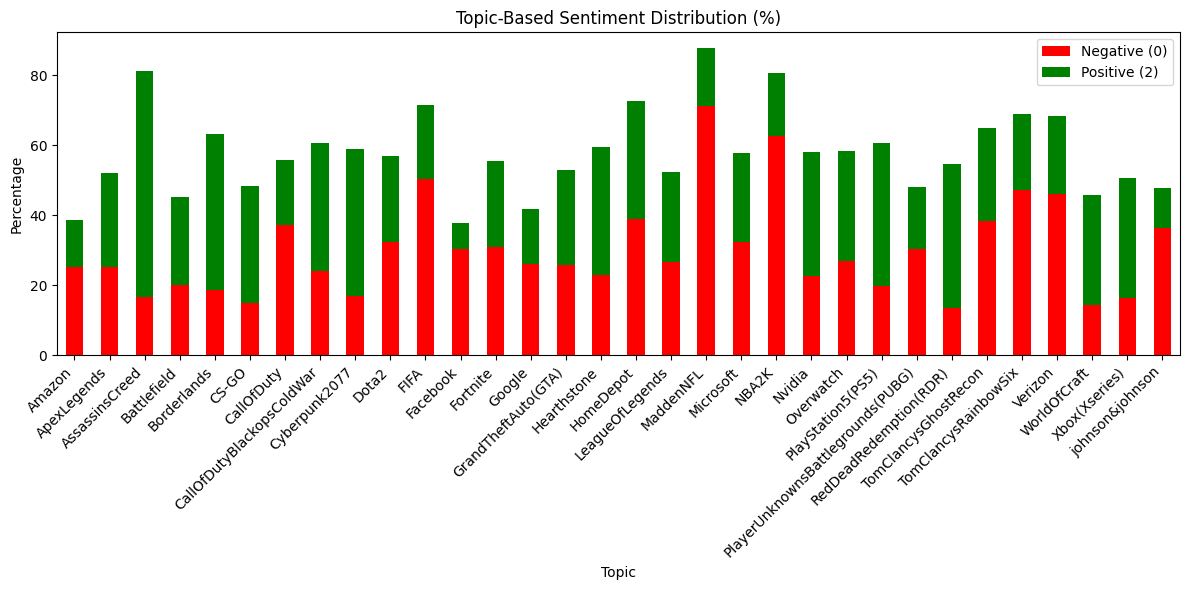

In [62]:
import matplotlib.pyplot as plt
import pandas as pd

df_pandas = df.to_pandas()

topic_sentiment_counts = df_pandas.groupby('topic')['sentiment'].value_counts(normalize=True).unstack().fillna(0) * 100
topic_sentiment_counts = topic_sentiment_counts[[0, 2]]
topic_sentiment_counts.plot(kind='bar', stacked=True, figsize=(12, 6), color=['red', 'green'])
plt.title("Topic-Based Sentiment Distribution (%)")
plt.ylabel("Percentage")
plt.xlabel("Topic")
plt.xticks(rotation=45, ha='right')
plt.legend(["Negative (0)", "Positive (2)"])
plt.tight_layout()
plt.show()
